In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

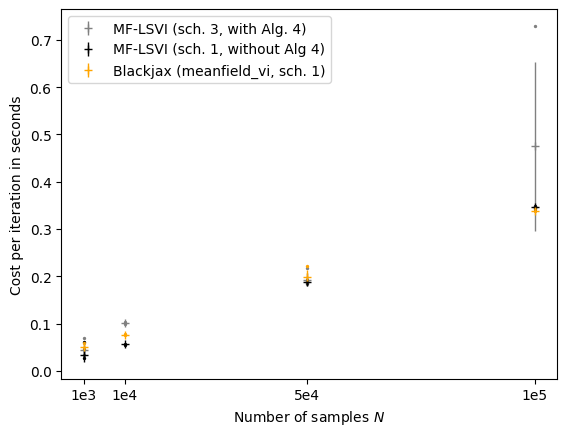

In [45]:
range_x = [1000, 10000, 50000, 100000]
labels = ["MF-LSVI (sch. 3, with Alg. 4)", "MF-LSVI (sch. 1, without Alg 4)", "Blackjax (meanfield_vi, sch. 1)"]
colors = ["gray", "black", "orange"]
for i in range(3):
    plt.errorbar(x=range_x, y=average_elapsed_time[i] / 100, yerr=std_elapsed_time[i] / 100, elinewidth=1,
                 label=labels[i], fmt=' ', marker='+', color=colors[i])
    plt.scatter(x=range_x, y=min_elapsed_time[i]/100, marker='o', color=colors[i], s=2)
    plt.scatter(x=range_x, y=max_elapsed_time[i]/100, marker='o', color=colors[i], s=2)
plt.xlabel(r"Number of samples $N$")
plt.ylabel("Cost per iteration in seconds")
plt.xticks(range_x, ["1e3", "1e4", "5e4", "1e5"])
plt.legend()
plt.savefig("cost_per_iteration_mean_field_mnist.pdf")

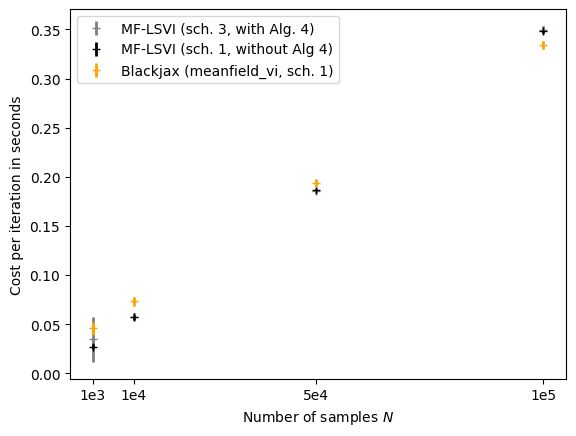

In [4]:
with open('walltime_results.pkl', 'rb') as f:
    data = pickle.load(f)
range_x = [1000, 10000, 50000, 100000]
labels = ["MF-LSVI (sch. 3, with Alg. 4)", "MF-LSVI (sch. 1, without Alg 4)", "Blackjax (meanfield_vi, sch. 1)"]
colors = ["gray", "black", "orange"]
for idx in range(len(data)):
    plt.errorbar(x=range_x, y= data[idx, :].mean(axis=-1)/100, yerr=2*data[idx,:].std(axis=-1)/100, label=labels[idx], color=colors[idx],
                fmt=' ', marker='+', elinewidth=2)
plt.xlabel(r"Number of samples $N$")
plt.ylabel("Cost per iteration in seconds")
plt.xticks(range_x, ["1e3", "1e4", "5e4", "1e5"])
plt.legend()
plt.savefig("cost_per_iteration_mean_field_mnist.pdf")

In [ ]:
# Plot losses using walltime
import os
lossesPKLs = []
lossesPKL_titles = []
for file in os.listdir("./output_mean_field/losses/"):
    if file.endswith(".pkl"):
        lossesPKLs.append(pickle.load(open("./losses/" + file, "rb")))
        lossesPKL_titles.append(str(file))
        
mapping_between_loss_idx_and_time_idx = {0:0, 1:1,2:2}
cost = [data[mapping_between_loss_idx_and_time_idx[i], :].mean(axis=-1)/100 for i in range(len(lossesPKLs))]
for i in range(len(lossesPKLs)):
    plt.errorbar(x=np.arange(1, len(lossesPKLs[i]+1)) *cost[i], y=lossesPKLs[i].mean(axis=-1), yerr=lossesPKLs[i].std(axis=-1), label=labels[i], color = colors[i])
plt.xlabel("Elapsed time (seconds)")
plt.ylabel("KL divergence")
plt.legend()